# 01 — Ma'lumotlarni tadqiq qilish (EDA)
**Fintech yo'nalishi: alert eskalatsiya ehtimolini bashorat qilish.**
Ushbu notebookdagi har bir grafik `../site/img/` papkasiga saqlanadi va EDA saytida ishlatiladi.
`notebooks/` papkasidan ishga tushiring (`Restart & Run All`). Ish vaqti ≈ 3 daqiqa.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os, warnings
warnings.filterwarnings('ignore')
DATA = '../data'; IMG = '../site/img'; OUT = '../outputs'
os.makedirs(IMG, exist_ok=True)

# barcha grafiklar uchun yagona rang palitrasi
C0, C1, GREY, ACC = '#4C72B0', '#DD8452', '#8C8C8C', '#55A868'
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10})
def save(name): plt.savefig(f'{IMG}/{name}.png'); plt.show()

## 1. Dataset tuzilmasi

In [2]:
tr = pd.read_csv(f'{DATA}/train_signals.csv', parse_dates=['signal_sanasi'])
te = pd.read_csv(f'{DATA}/test_signals.csv',  parse_dates=['signal_sanasi'])
tx = pd.read_parquet(f'{DATA}/train_transactions.parquet')
n_tx_test = pd.read_parquet(f'{DATA}/test_transactions.parquet', columns=['signal_id']).shape[0]

print(f'train signallar: {len(tr):,}   test signallar: {len(te):,}')
print(f'train tranzaksiyalar: {len(tx):,}   test tranzaksiyalar: {n_tx_test:,}')
print(f'signal sanalari: {tr.signal_sanasi.min().date()} → {tr.signal_sanasi.max().date()}')
print(f'tranzaksiya vaqtlari: {tx.tranzaksiya_vaqti.min()} → {tx.tranzaksiya_vaqti.max()}')
display(tr.head(3)); display(tx.head(3))

train signallar: 14,000   test signallar: 6,000
train tranzaksiyalar: 6,987,663   test tranzaksiyalar: 3,027,575
signal sanalari: 2025-01-01 → 2026-12-31
tranzaksiya vaqtlari: 2024-07-05 00:31:36 → 2026-12-31 00:00:00


,signal_id,signal_sanasi,eskalatsiya
0,SG_000002,2026-08-02,0
1,SG_000003,2025-12-15,0
2,SG_000004,2026-02-13,0


,signal_id,tranzaksiya_vaqti,kirim_chiqim,tranzaksiya_turi,miqdor_indeksi
0,SG_016527,2024-07-06 08:47:18,chiqim,bank_otkazmasi,0.236245
1,SG_016527,2024-07-07 02:13:02,chiqim,bank_otkazmasi,1.130377
2,SG_016527,2024-07-08 11:15:12,kirim,karta,0.466360


count    14000.0
mean       499.1
std        299.5
min          1.0
25%        277.0
50%        461.0
75%        678.2
max       2279.0
dtype: float64


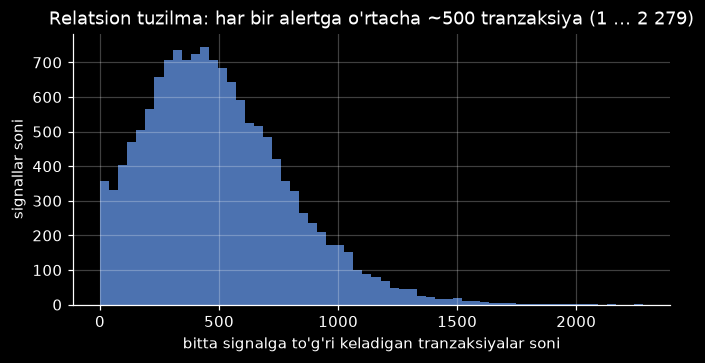

In [3]:
# har bir tranzaksiyaga signal sanasini biriktirib, "signalgacha necha kun" ni hisoblaymiz
tx = tx.merge(tr, on='signal_id')
tx['d'] = (tx.signal_sanasi - tx.tranzaksiya_vaqti).dt.total_seconds() / 86400
per_sig = tx.groupby('signal_id').size()
print(per_sig.describe().round(1))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(per_sig, bins=60, color=C0)
ax.set(xlabel='bitta signalga to\'g\'ri keladigan tranzaksiyalar soni', ylabel='signallar soni',
       title='Relatsion tuzilma: har bir alertga o\'rtacha ~500 tranzaksiya (1 … 2 279)')
save('01_tx_per_signal')

**Kuzatuv.** Har bir alert 180 kunlik oynada o'rtacha ~500 ta tarixiy tranzaksiyaga ega. Demak, masala *to'plam → label*
ko'rinishida: model ishlatishdan oldin hamma narsani `signal_id` darajasida umumlashtirish (agregatsiya) kerak.

## 2. Target taqsimoti

eskalatsiya: 2,405 / 14,000  = 17.2%


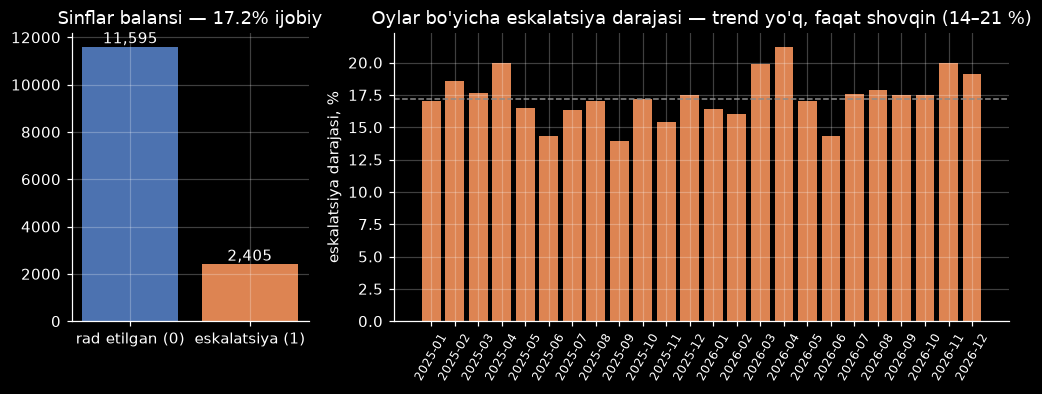

In [4]:
rate = tr.eskalatsiya.mean()
print(f'eskalatsiya: {tr.eskalatsiya.sum():,} / {len(tr):,}  = {rate:.1%}')
m = tr.groupby(tr.signal_sanasi.dt.to_period('M')).eskalatsiya.agg(['size', 'mean'])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={'width_ratios': [1, 2.6]})
ax[0].bar(['rad etilgan (0)', 'eskalatsiya (1)'], tr.eskalatsiya.value_counts().sort_index(), color=[C0, C1])
ax[0].set_title(f'Sinflar balansi — {rate:.1%} ijobiy')
for i, v in enumerate(tr.eskalatsiya.value_counts().sort_index()): ax[0].text(i, v, f'{v:,}', ha='center', va='bottom')
ax[1].bar(range(len(m)), m['mean'] * 100, color=C1)
ax[1].axhline(rate * 100, color=GREY, ls='--', lw=1)
ax[1].set_xticks(range(len(m))); ax[1].set_xticklabels([str(p) for p in m.index], rotation=60, fontsize=8)
ax[1].set(ylabel='eskalatsiya darajasi, %', title='Oylar bo\'yicha eskalatsiya darajasi — trend yo\'q, faqat shovqin (14–21 %)')
save('02_target')

**Kuzatuv.** Alertlarning 17.2 % i eskalatsiya qilingan. Bu ko'rsatkich ikki yil davomida tekis (oyma-oy 14–21 %, bu oyiga
~500 alert uchun oddiy binomial shovqin), hafta kunlari bo'yicha ham bir xil. Ya'ni **signal sanasi hech qanday ma'lumot bermaydi**.
Shuning uchun yakuniy modelda kalendar featurelari ishlatilmagan.

## 3. Tranzaksiya turlari va yo'nalishi

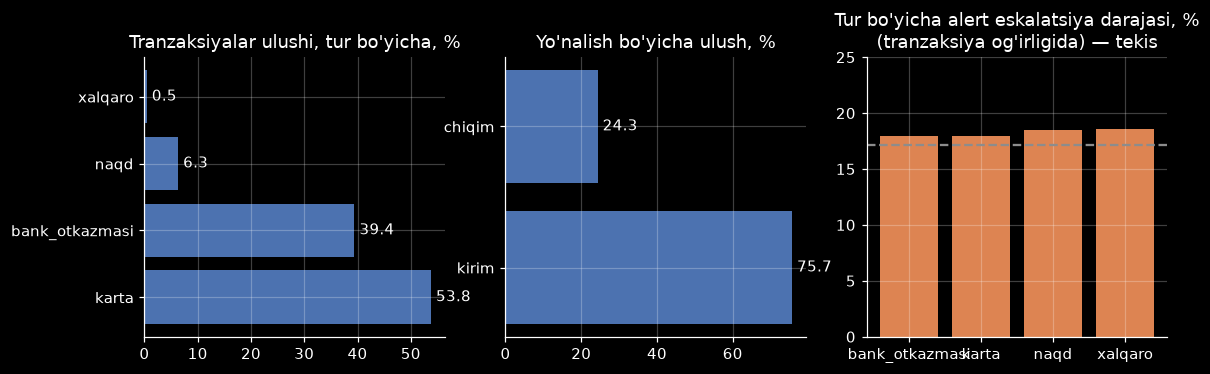

In [5]:
ts = tx.tranzaksiya_turi.value_counts(normalize=True) * 100
ds = tx.kirim_chiqim.value_counts(normalize=True) * 100
esc_by_type = tx.groupby('tranzaksiya_turi').eskalatsiya.mean() * 100

fig, ax = plt.subplots(1, 3, figsize=(12, 3.3))
ax[0].barh(ts.index, ts.values, color=C0); ax[0].set_title('Tranzaksiyalar ulushi, tur bo\'yicha, %')
for i, v in enumerate(ts.values): ax[0].text(v, i, f' {v:.1f}', va='center')
ax[1].barh(ds.index, ds.values, color=C0); ax[1].set_title('Yo\'nalish bo\'yicha ulush, %')
for i, v in enumerate(ds.values): ax[1].text(v, i, f' {v:.1f}', va='center')
ax[2].bar(esc_by_type.index, esc_by_type.values, color=C1); ax[2].axhline(rate*100, color=GREY, ls='--')
ax[2].set_ylim(0, 25); ax[2].set_title('Tur bo\'yicha alert eskalatsiya darajasi, %\n(tranzaksiya og\'irligida) — tekis')
save('03_types')

**Kuzatuv.** Karta (54 %) va bank o'tkazmalari (39 %) ustunlik qiladi; naqd 6 %, xalqaro 0.5 %. Qatorlarning 76 % i kirim.
Alertning eskalatsiya darajasi **har bir tur va yo'nalish uchun bir xil (18–19 %)** — turlarning *aralashmasi* sinflarni ajratmaydi.
Bu "naqd / xalqaro ulushi" kabi tabiiy featurelarni boshidanoq chetga surdi.

## 4. Tranzaksiya hajmi taqsimoti (`miqdor_indeksi`)

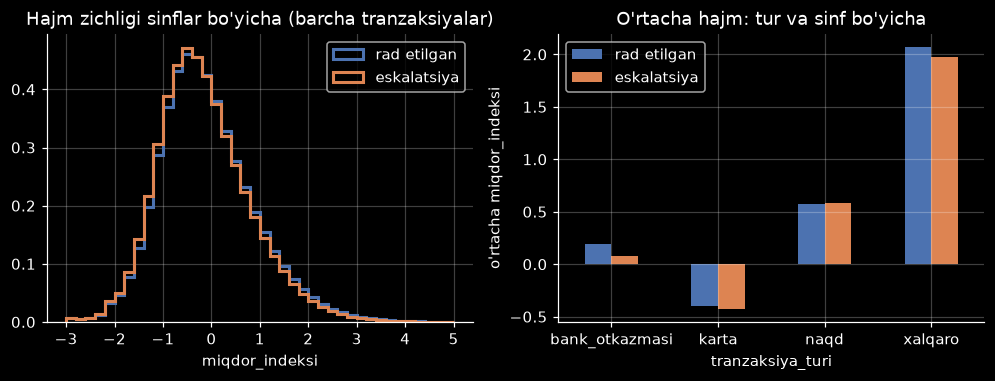

eskalatsiya           0      1
tranzaksiya_turi              
bank_otkazmasi    0.193  0.074
karta            -0.400 -0.426
naqd              0.576  0.579
xalqaro           2.070  1.980


In [6]:
nb = tx[tx.d > 3/1440]          # oxirgi 3 daqiqadagi burst artefaktini chiqarib tashlaymiz (5-bo'lim)
bins = np.linspace(-3, 5, 41)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for y, c, lab in [(0, C0, 'rad etilgan'), (1, C1, 'eskalatsiya')]:
    ax[0].hist(nb.miqdor_indeksi[nb.eskalatsiya == y], bins, density=True, histtype='step', lw=2, color=c, label=lab)
ax[0].legend(); ax[0].set(title='Hajm zichligi sinflar bo\'yicha (barcha tranzaksiyalar)', xlabel='miqdor_indeksi')
tm = nb.groupby(['eskalatsiya', 'tranzaksiya_turi']).miqdor_indeksi.mean().unstack(0)
tm.plot.bar(ax=ax[1], color=[C0, C1], rot=0); ax[1].set(title='O\'rtacha hajm: tur va sinf bo\'yicha', ylabel='o\'rtacha miqdor_indeksi')
ax[1].legend(['rad etilgan', 'eskalatsiya'])
save('04_amount')
print(tm.round(3))

**Kuzatuv.** Ikki sinfning zichliklari deyarli ustma-ust tushadi (eskalatsiya qilingan alertlarda tranzaksiyalar o'rtacha
sal kichikroq). Qiziq joyi o'ng panelda: sinflar orasidagi farq **bank o'tkazmalarida** to'plangan (0.19 vs 0.07), karta va naqd
esa bir xil. Bu "*boshqa turlarga nisbatan* bank o'tkazmasi hajmi muhim" degan birinchi ishora.

## 5. Signaldan oldingi faollik

signaldan oldingi oxirgi 3 daqiqadagi tranzaksiyalar: 552,630 (barcha qatorlarning 7.9%), 13,868 / 14,000 signalda, o'rtacha 39.8 ta


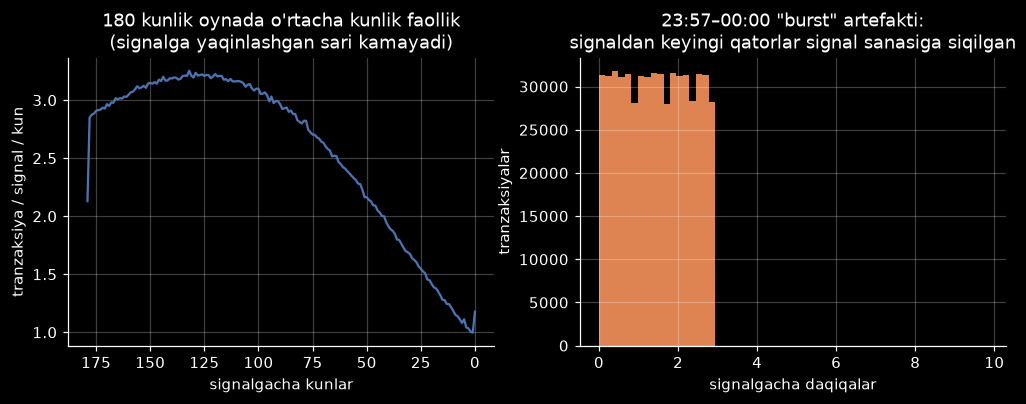

In [7]:
nb_daily = nb.groupby(np.floor(nb.d)).size() / len(tr)
burst = tx[tx.d <= 3/1440]
print(f'signaldan oldingi oxirgi 3 daqiqadagi tranzaksiyalar: {len(burst):,} (barcha qatorlarning {len(burst)/len(tx):.1%}), '
      f'{burst.signal_id.nunique():,} / {len(tr):,} signalda, o\'rtacha {burst.groupby("signal_id").size().mean():.1f} ta')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(nb_daily.index, nb_daily.values, color=C0)
ax[0].set(xlabel='signalgacha kunlar', ylabel='tranzaksiya / signal / kun', title='180 kunlik oynada o\'rtacha kunlik faollik\n(signalga yaqinlashgan sari kamayadi)')
ax[0].invert_xaxis()
sec = (tx.signal_sanasi - tx.tranzaksiya_vaqti).dt.total_seconds()
ax[1].hist(sec[(sec >= 0) & (sec < 600)] / 60, bins=60, color=C1)
ax[1].set(xlabel='signalgacha daqiqalar', ylabel='tranzaksiyalar', title='23:57–00:00 "burst" artefakti:\nsignaldan keyingi qatorlar signal sanasiga siqilgan')
save('05_before_signal')

**Ikkita topilma.**
1. Kunlik faollik tekis *emas*: 120–150 kun oldin ~3.2 tranzaksiya/kun, signalga yaqinlashgan sari monoton kamayib, oxirgi
kunlarda ~1/kun ga tushadi. Bu pasayish ikkala sinf uchun bir xil (oxirgi 1/7/30 kunlik faollik nisbatlari AUC ≈ 0.50–0.53),
shuning uchun "signaldan bevosita oldingi faollik" bu datada ajratuvchi feature emas.
2. **Artefakt:** barcha qatorlarning 8 % i signal sanasi yarim tunidan oldingi oxirgi 3 daqiqada joylashgan (har alertga ~40 ta).
Bu aniq sintetik siqish: signaldan keyingi tranzaksiyalar signal sanasiga "yig'ib qo'yilgan". Biz ularni `burst` deb belgilab, asosiy
featurelarni ularsiz hisoblaymiz; ularni haqiqiy "alertdan oldingi faollik" deb qabul qilgan sequence model shovqinni o'rganadi.

## 6. Kun soati va hafta kuni

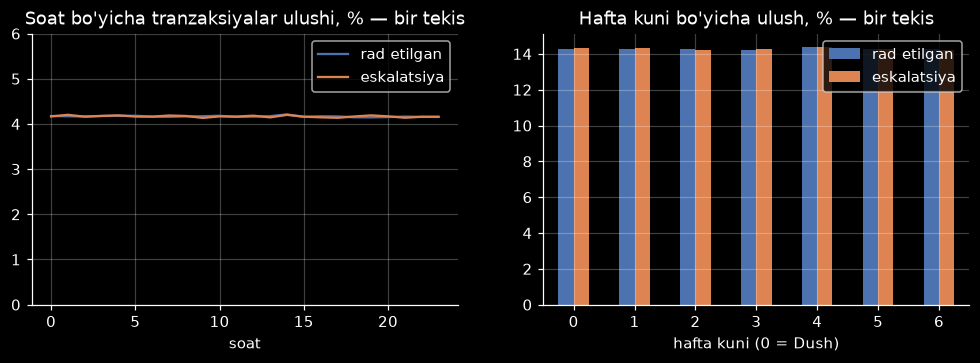

In [8]:
h = nb.groupby([nb.tranzaksiya_vaqti.dt.hour, 'eskalatsiya']).size().unstack()
h = h / h.sum() * 100
w = nb.groupby([nb.tranzaksiya_vaqti.dt.dayofweek, 'eskalatsiya']).size().unstack(); w = w / w.sum() * 100
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
h.plot(ax=ax[0], color=[C0, C1]); ax[0].set(title='Soat bo\'yicha tranzaksiyalar ulushi, % — bir tekis', xlabel='soat', ylim=(0, 6))
w.plot.bar(ax=ax[1], color=[C0, C1], rot=0); ax[1].set(title='Hafta kuni bo\'yicha ulush, % — bir tekis', xlabel='hafta kuni (0 = Dush)')
for a in ax: a.legend(['rad etilgan', 'eskalatsiya'])
save('06_time')

**Kuzatuv.** Kun soati va hafta kuni ikkala sinf uchun mutlaqo bir tekis (har soatga 4.17 %): sintetik generator vaqtni
tekis taqsimotdan olgan. AML'da klassik "qizil bayroq" hisoblangan tungi/dam olish kunidagi faollik bu datada **nol signal** beradi.

## 7. Asosiy topilma — bank o'tkazmasi hajmi mijozning o'z naqd va karta faolligiga *nisbatan*

Shu bitta feature ROC-AUC: 0.609


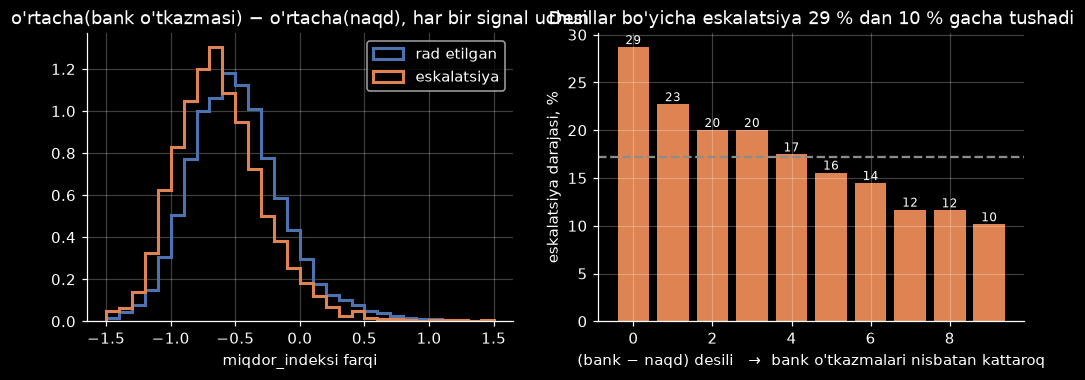

In [9]:
tm = nb.pivot_table(index='signal_id', columns='tranzaksiya_turi', values='miqdor_indeksi', aggfunc='mean')
y = tr.set_index('signal_id').eskalatsiya.reindex(tm.index)
rel = (tm.bank_otkazmasi - tm.naqd).rename('bank_minus_naqd')
from sklearn.metrics import roc_auc_score
ok = rel.notna()
print(f'Shu bitta feature ROC-AUC: {roc_auc_score(y[ok], -rel[ok]):.3f}')
dec = pd.qcut(rel, 10, labels=False)
dec_rate = y.groupby(dec).mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
b = np.linspace(-1.5, 1.5, 31)
for k, c, lab in [(0, C0, 'rad etilgan'), (1, C1, 'eskalatsiya')]:
    ax[0].hist(rel[y == k].dropna(), b, density=True, histtype='step', lw=2, color=c, label=lab)
ax[0].legend(); ax[0].set(title='o\'rtacha(bank o\'tkazmasi) − o\'rtacha(naqd), har bir signal uchun', xlabel='miqdor_indeksi farqi')
ax[1].bar(range(10), dec_rate.values, color=C1); ax[1].axhline(rate*100, color=GREY, ls='--')
ax[1].set(xlabel='(bank − naqd) desili   →  bank o\'tkazmalari nisbatan kattaroq', ylabel='eskalatsiya darajasi, %',
          title=f'Desillar bo\'yicha eskalatsiya {dec_rate.iloc[0]:.0f} % dan {dec_rate.iloc[-1]:.0f} % gacha tushadi')
for i, v in enumerate(dec_rate.values): ax[1].text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8)
save('07_relative')

**Kuzatuv.** Mutlaq hajmlar sinflarni deyarli ajratmaydi, lekin *bitta mijoz ichidagi tranzaksiya turlari orasidagi farq*
ajratadi: bank o'tkazmalari o'z naqd va karta tranzaksiyalariga nisbatan kichik bo'lgan alertlar deyarli 3 barobar ko'proq
eskalatsiya qilinadi (eng past desilda 28.7 %, eng yuqorida 10.2 %). Bitta feature'ning o'zi ROC-AUC 0.61 beradi.
Bu modelning asosiy feature oilasini belgiladi: tur / yo'nalish bo'yicha statistikalarning (o'rtacha, mediana, kvartillar, std)
juft-juft farqlari.

## 8. Hajm indeksining guruh bo'yicha pastki chegaralari

min    max
tranzaksiya_turi kirim_chiqim              
bank_otkazmasi   chiqim       -2.839  6.692
                 kirim        -2.912  6.692
karta            chiqim       -2.269  4.183
                 kirim        -2.227  4.183
naqd             chiqim       -1.320  4.863
                 kirim        -1.257  4.563
xalqaro          chiqim       -0.548  6.430
                 kirim        -0.355  6.430

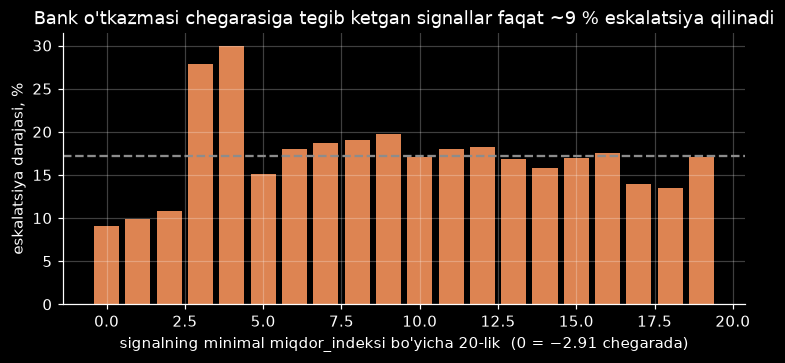

In [10]:
grp = nb.groupby(['tranzaksiya_turi', 'kirim_chiqim']).miqdor_indeksi.agg(['min', 'max']).round(3)
display(grp)
gmin = tx.groupby('signal_id').miqdor_indeksi.min().reindex(tm.index)
q = pd.qcut(gmin, 20, labels=False, duplicates='drop')
r = y.groupby(q).mean() * 100
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(range(len(r)), r.values, color=C1); ax.axhline(rate*100, color=GREY, ls='--')
ax.set(xlabel='signalning minimal miqdor_indeksi bo\'yicha 20-lik  (0 = −2.91 chegarada)', ylabel='eskalatsiya darajasi, %',
       title='Bank o\'tkazmasi chegarasiga tegib ketgan signallar faqat ~9 % eskalatsiya qilinadi')
save('08_floor')

**Kuzatuv.** `miqdor_indeksi` har bir tur × yo'nalish uchun alohida standartlashtirilgan: har guruhning o'z pastki chegarasi bor
(bank-kirim −2.91, bank-chiqim −2.84, karta −2.23/−2.27, naqd −1.26/−1.32). Kamida bitta tranzaksiyasi bank-kirim chegarasida
bo'lgan signallar (alertlarning ~14 %) faqat 9 % hollarda eskalatsiya qilinadi, chegaradan sal yuqoridagilar esa 29 %. Bu o'tkir,
monoton bo'lmagan effekt; daraxtli modellar uni `all_amt_min` orqali o'rganadi (muhimlik bo'yicha 3-feature).

## 9. Model nimani o'rgandi (`outputs/` dan)

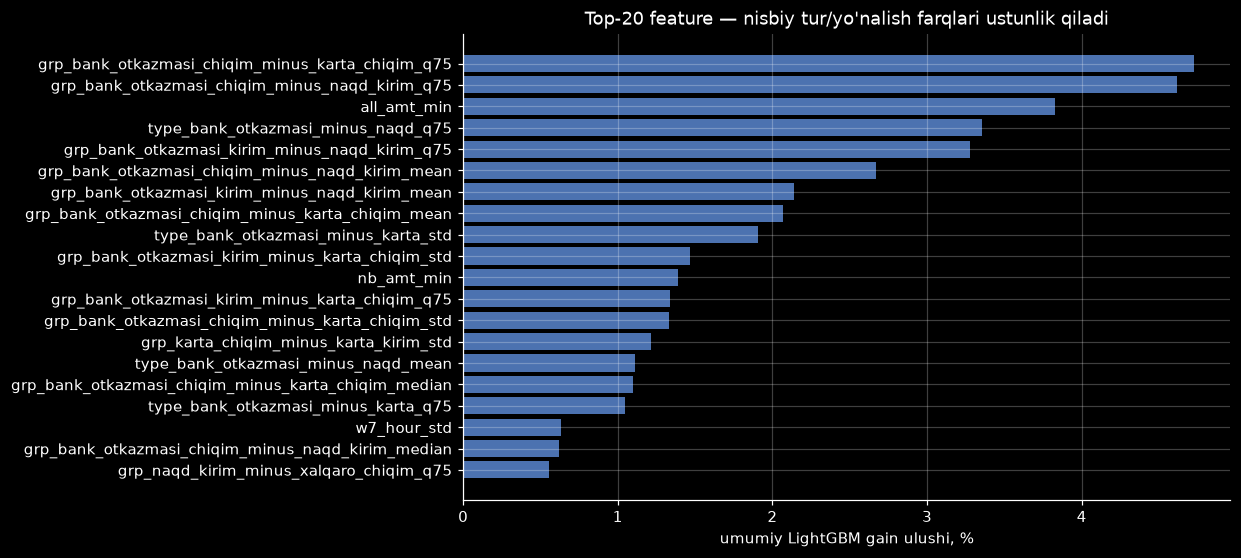

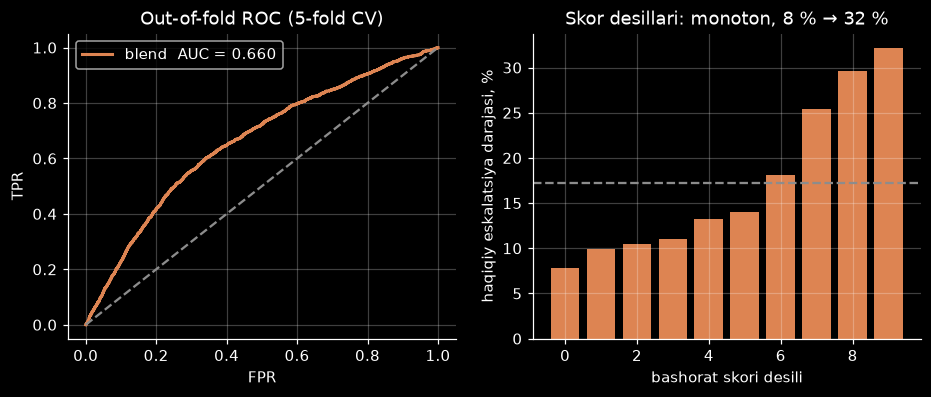

5-fold stratified CV, 60 selected features
all-feature LightGBM (early stopping): 0.6520
LightGBM top-60:                0.6610
LogReg top-60:                  0.6470
rank blend (0.7/0.3):                 0.6602



In [11]:
imp = pd.read_csv(f'{OUT}/feature_importance.csv', index_col=0).iloc[:, 0]
top = imp.head(20)[::-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top.index, top.values / imp.sum() * 100, color=C0)
ax.set(xlabel='umumiy LightGBM gain ulushi, %', title='Top-20 feature — nisbiy tur/yo\'nalish farqlari ustunlik qiladi')
save('09_importance')

from sklearn.metrics import roc_curve
oof = pd.read_csv(f'{OUT}/oof_predictions.csv')
fpr, tpr, _ = roc_curve(oof.eskalatsiya, oof.oof_blend)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(fpr, tpr, color=C1, lw=2, label=f'blend  AUC = {roc_auc_score(oof.eskalatsiya, oof.oof_blend):.3f}')
ax[0].plot([0, 1], [0, 1], color=GREY, ls='--'); ax[0].legend(); ax[0].set(xlabel='FPR', ylabel='TPR', title='Out-of-fold ROC (5-fold CV)')
bins_p = pd.qcut(oof.oof_blend, 10, labels=False)
cal = oof.groupby(bins_p).eskalatsiya.mean() * 100
ax[1].bar(range(10), cal.values, color=C1); ax[1].axhline(rate*100, color=GREY, ls='--')
ax[1].set(xlabel='bashorat skori desili', ylabel='haqiqiy eskalatsiya darajasi, %',
          title=f'Skor desillari: monoton, {cal.iloc[0]:.0f} % → {cal.iloc[-1]:.0f} %')
save('10_roc_calibration')
print(open(f'{OUT}/cv_report.txt').read())

## 10. Topilmalar xulosasi
| # | Topilma | Modellashtirishga ta'siri |
|---|---|---|
| 1 | Har alertga ~500 tranzaksiya, relatsion tuzilma | `signal_id` bo'yicha agregatsiya; 850 ta nomzod feature |
| 2 | Eskalatsiya darajasi vaqt, hafta kuni, soat bo'yicha tekis | kalendar featurelari yo'q |
| 3 | Tur / yo'nalish *aralashmasi* sinflarda bir xil | ulushlar kuchsiz; yakuniy to'plamdan chiqarilgan |
| 4 | Farq **bank o'tkazmasi hajmining mijozning boshqa turlariga nisbatida** | tur/yo'nalish juft farqlari → eng kuchli oila |
| 5 | `miqdor_indeksi` guruh chegaralari; chegaraga tegish ⇒ past eskalatsiya | min/kvantil featurelari saqlanadi; daraxtlar nomonoton effektni oladi |
| 6 | 23:57–00:00 burst = siqilgan signaldan keyingi qatorlar | artefakt deb belgilanadi; featurelar ularsiz hisoblanadi |
| 7 | Chiziqli model ≈ boosting (0.647 vs 0.661) | signal kuchsiz va asosan chiziqli; label shovqini shiftni ≈ 0.66–0.70 da belgilaydi |
